In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

In [2]:
# Reading the file
import pandas as pd
data = pd.read_csv(r"C:\Users\Disha\IISER - B Summer Internship\US Wheat Futures Historical Data.csv")

In [3]:
# Converting "Price", "Open", "High", "Low", "Vol." columns to float datatype
data['Price'] = data['Price'].str.replace(',', '').astype(float)
data['Open'] = data['Open'].str.replace(',', '').astype(float)
data['High'] = data['High'].str.replace(',', '').astype(float)
data['Low'] = data['Low'].str.replace(',', '').astype(float)
data['Vol.'] = data['Vol.'].str.replace('K', '').astype(float) * 1000.
print(data.dtypes)

Date         object
Price       float64
Open        float64
High        float64
Low         float64
Vol.        float64
Change %     object
dtype: object


In [4]:
# Convert the "date" column to a datetime object
data['Date'] = pd.to_datetime(data['Date'])

In [5]:
# Check for null values in each column
null_counts = data.isnull().sum()

# Print the number of null values in each column
print(null_counts)

Date          0
Price         0
Open          0
High          0
Low           0
Vol.        520
Change %      0
dtype: int64


In [6]:
# fill missing values with mean of the column
data = data.fillna(data.mean())

# Check for null values in each column again
null_counts = data.isnull().sum()

# Print the number of null values in each column
print(null_counts)

Date        0
Price       0
Open        0
High        0
Low         0
Vol.        0
Change %    0
dtype: int64


In [7]:
# Drop columns from the dataset
data = data.drop('Change %', axis=1)

# Show the updated dataset
print(data.head())

        Date   Price    Open    High     Low      Vol.
0 2022-12-25  792.00  781.25  799.00  765.50   97480.0
1 2022-12-18  776.00  755.00  778.00  738.75  165670.0
2 2022-12-11  753.50  742.50  772.00  737.60   32610.0
3 2022-12-04  734.25  763.25  768.00  723.50  189690.0
4 2022-11-27  761.00  793.25  799.25  755.75  213750.0


In [8]:
# Extract the independent and dependent variables
X = data[['Open', 'High', 'Low', 'Vol.']].values
y = data['Price'].values.reshape(-1, 1)

In [9]:
# Addition
# Select the rows for the training set (2000-2019)
train_X = X[data['Date'].dt.year.between(2000, 2019)]
train_y = y[data['Date'].dt.year.between(2000, 2019)]

# Select the rows for the test set (2020-2022)
test_X = X[data['Date'].dt.year.between(2020, 2022)]
test_y = y[data['Date'].dt.year.between(2020, 2022)]

In [10]:
"""
# split the data into 80% training and 20% test sets
from sklearn.model_selection import train_test_split

# split the data into training and test sets
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=42)
"""

'\n# split the data into 80% training and 20% test sets\nfrom sklearn.model_selection import train_test_split\n\n# split the data into training and test sets\ntrain_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=42)\n'

In [11]:
# Perform polynomial feature transformation
poly_features = PolynomialFeatures(degree=2)
X_train_poly = poly_features.fit_transform(train_X)
X_test_poly = poly_features.transform(test_X)

In [12]:
# Fit the polynomial regression model on the training data
model = LinearRegression()
model.fit(X_train_poly, train_y)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

In [13]:
# Predict the target variable for the test data
pred = model.predict(X_test_poly)

In [14]:
from sklearn.metrics import r2_score, mean_squared_error

# Evaluate the model's performance
r2 = r2_score(test_y, pred)
rmse = np.sqrt(mean_squared_error(test_y, pred))

print("R-squared: ", r2)
print("RMSE: ", rmse)

R-squared:  0.9335547182992733
RMSE:  44.20265852560554


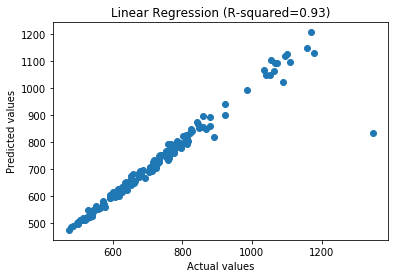

In [15]:
# Plot actual vs predicted values
import matplotlib.pyplot as plt

plt.scatter(test_y, pred)
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title(f"Linear Regression (R-squared={r2:.2f})")
plt.show()